## Imports

In [45]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

RANDOM_SEED = 42

## Generate the Data Matrix and the Label vector

In [46]:
D_list = []
y_list = []

for subject_id in range(1, 41):
    folder = f'data/s{subject_id}'
    for img_id in range(1, 11):
        img_path = os.path.join(folder, f'{img_id}.pgm')
        img = Image.open(img_path)
        img_arr = np.asarray(img).flatten()
        D_list.append(img_arr)
        y_list.append(subject_id)

D = np.array(D_list)
y = np.array(y_list)
print("Data Matrix Shape: ", D.shape)
print("Label Vector Shape: ", y.shape)

Data Matrix Shape:  (400, 10304)
Label Vector Shape:  (400,)


## Split the Dataset into Training and Test sets

In [47]:
"""
From the Data Matrix D400x10304 keep the odd rows for training and the even rows for
testing. This will give you 5 instances per person for training and 5 instances per person
for testing
"""
X_train_lst = []
X_test_lst = []
y_train_lst = []
y_test_lst = []

for row in range(D.shape[0]):
    if row % 2 == 1:
        X_train_lst.append(D[row])
        y_train_lst.append(y[row])
    else:
        X_test_lst.append(D[row])
        y_test_lst.append(y[row])

X_train = np.array(X_train_lst)
X_test = np.array(X_test_lst)
y_train = np.array(y_train_lst)
y_test = np.array(y_test_lst)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(200, 10304)
(200,)
(200, 10304)
(200,)


## PCA Implementation

In [48]:
class PCA:
    def __init__(self, cache_dir=None):
        self.mean = None
        self.eigenvalues = None
        self.eigenvectors = None
        self.explained_variance = None
        self.cumulative_variance = None
        self.cache_dir = cache_dir

        # If a cache path is given, try to load saved eigenvalues/vectors
        if cache_dir:
            try:
                self.eigenvalues = np.load(os.path.join(cache_dir, 'eigenvalues.npy'))
                self.eigenvectors = np.load(os.path.join(cache_dir, 'eigenvectors.npy'))
                self.mean = np.load(os.path.join(cache_dir, 'mean.npy'))
                # Calculate explained variance and cumulative variance
                self.explained_variance = self.eigenvalues / np.sum(self.eigenvalues)
                self.cumulative_variance = np.cumsum(self.explained_variance)
                print("Loaded PCA data from cache.")
            except FileNotFoundError:
                print("PCA cache not found. Will compute and save later.")

    def fit(self, X):
        if self.eigenvalues is not None and self.eigenvectors is not None and self.mean is not None:
            return # already computed

        # Mean-center the data
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        # Calculate covariance Matrix
        cov_matrix = np.cov(X_centered, rowvar=False)

        # Compute eigenvalues and eigenvectors
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # Sort the eigenvalues and eigenvectors in descending order
        sorted_indices = np.argsort(eigenvalues)[::-1]
        self.eigenvalues = eigenvalues[sorted_indices]
        self.eigenvectors = eigenvectors[:, sorted_indices]

        # Calculate explained variance and cumulative variance
        self.explained_variance = self.eigenvalues / np.sum(self.eigenvalues)
        self.cumulative_variance = np.cumsum(self.explained_variance)

        # Save to cache if specified
        if self.cache_dir:
            # Ensure the directory exists
            os.makedirs(self.cache_dir, exist_ok=True)
            np.save(os.path.join(self.cache_dir, 'eigenvalues.npy'), self.eigenvalues)
            np.save(os.path.join(self.cache_dir, 'eigenvectors.npy'), self.eigenvectors)
            np.save(os.path.join(self.cache_dir, 'mean.npy'), self.mean)
    
    def transform(self, X, threshold): 
        if self.eigenvectors is None:
            raise Exception("Must call fit() before transform().")
        
        n_components = np.argmax(self.cumulative_variance >= threshold) + 1
        pcs = self.eigenvectors[:, :n_components]
        X_centered = X - self.mean
        return np.dot(X_centered, pcs), n_components
    
    def inverse_transform(self, X_pca, n_components):
        if self.eigenvectors is None:
            raise Exception("Must call fit() before inverse_transform().")
        pcs = self.eigenvectors[:, :n_components]
        return np.dot(X_pca, pcs.T) + self.mean 


In [49]:
def visualize_faces(X_train, pca, n_faces = 5, pca_threshold=0.9):
    # Randomly choose n_faces indices from the training data
    np.random.seed(RANDOM_SEED)
    indices = np.random.choice(X_train.shape[0], size=n_faces, replace=False)
    sampled_faces = X_train[indices]

    sampled_faces_pca, n_components = pca.transform(sampled_faces, pca_threshold)

    # Approximately reconstruct the faces back to the original space
    reconstructed_faces = pca.inverse_transform(sampled_faces_pca, n_components)

    # Plot the reconstructed faces
    fig, axes = plt.subplots(1, n_faces, figsize=(15, 5))

    fig.suptitle(f"Reconstructed Faces (PCA Threshold = {pca_threshold * 100}%)", weight='bold')
    
    for i, face in enumerate(reconstructed_faces):
        axes[i].imshow(face.reshape(112, 92), cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f"Sample {indices[i]}")
    fig.tight_layout()
    plt.show()

Loaded PCA data from cache.
at Alpha = 0.8, Components Retained (Dimensionality) = 37


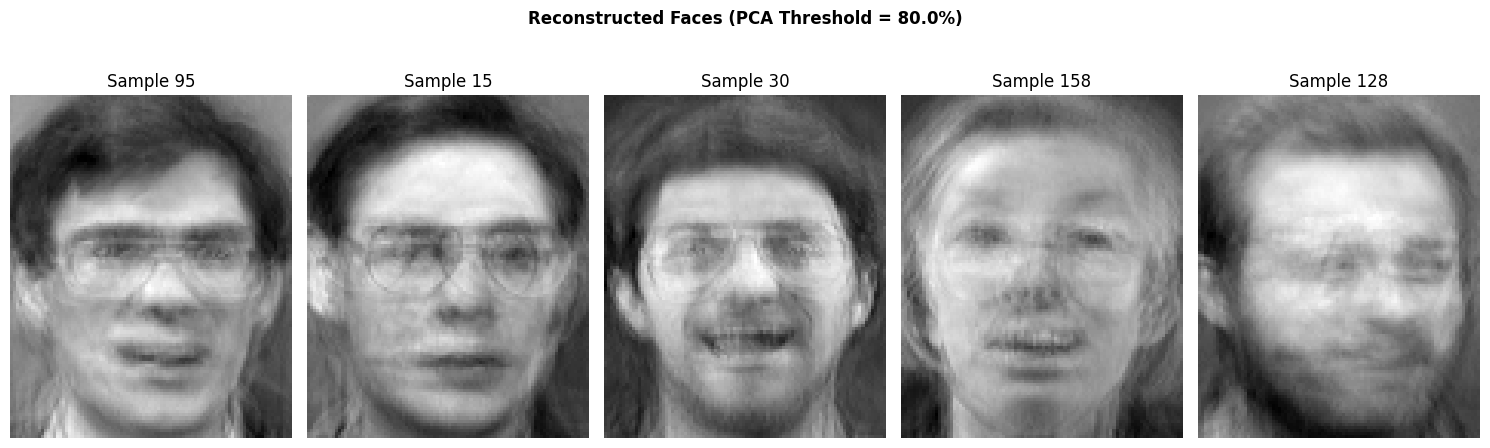

at Alpha = 0.85, Components Retained (Dimensionality) = 53


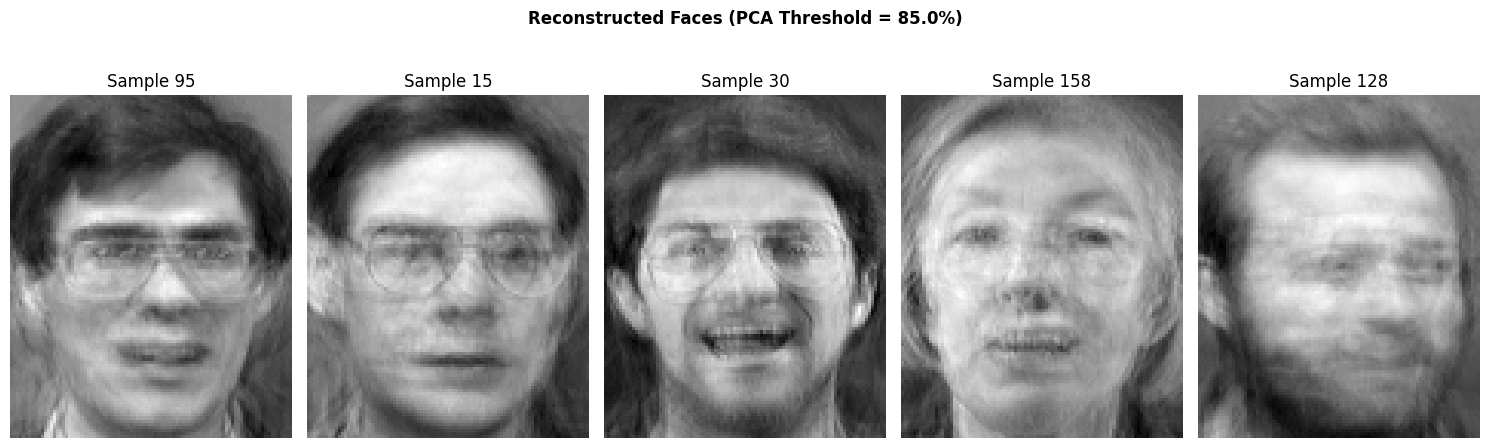

at Alpha = 0.9, Components Retained (Dimensionality) = 77


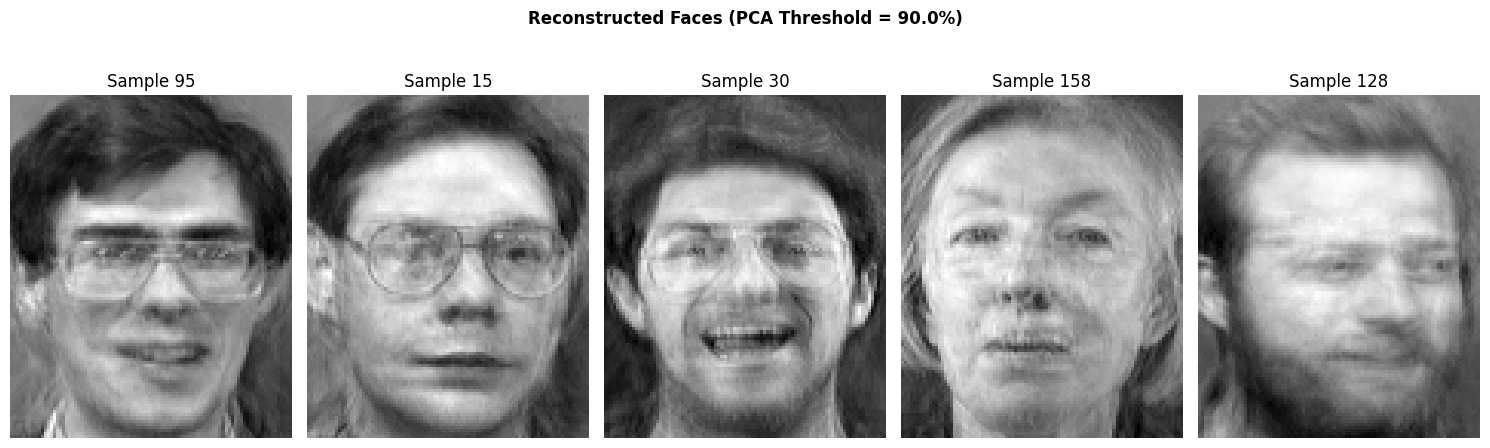

at Alpha = 0.95, Components Retained (Dimensionality) = 116


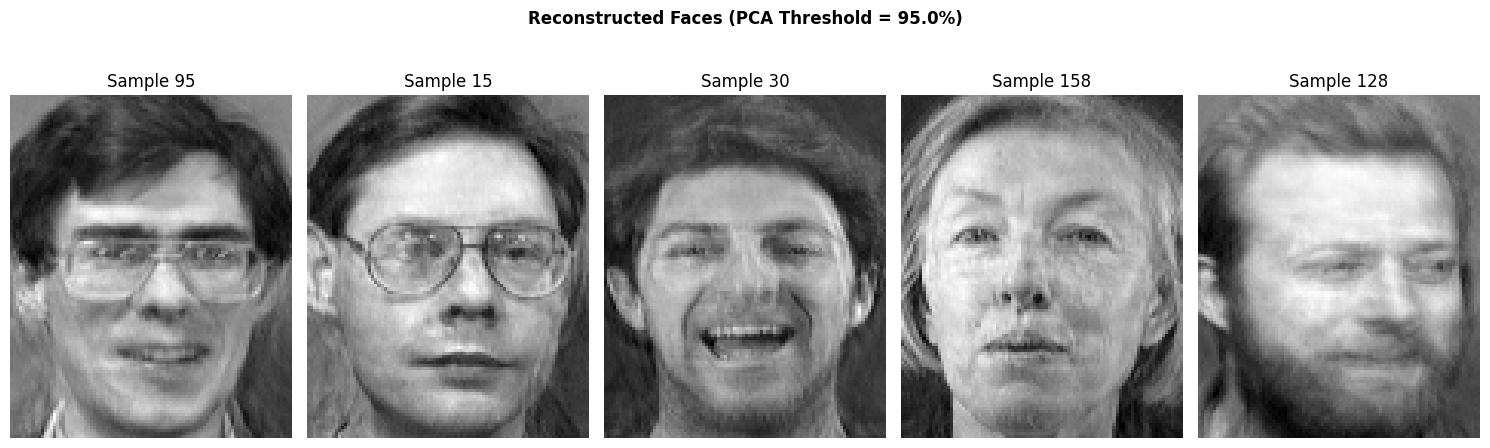

In [50]:
# Project the dataset into the reduced PCA subspace and report dimensionality 
# and visualize reconstructed samples for different thresholds
pca = PCA(cache_dir="pca_results")
pca.fit(X_train)

pca_projections = {} # will store X_train_pca, X_test_pca, n_components for each alpha

for alpha in [0.8, 0.85, 0.9, 0.95]:
    X_train_pca, n_components = pca.transform(X_train, alpha)
    X_test_pca, _ = pca.transform(X_test, alpha)
    pca_projections[alpha] = {
        "train": X_train_pca,
        "test": X_test_pca,
        "n_components": n_components
    }
    print(f"at Alpha = {alpha}, Components Retained (Dimensionality) = {n_components}")
    visualize_faces(X_train, pca, n_faces=5, pca_threshold=alpha)

## K-Means Clustering

In [51]:
import numpy as np
from abc import ABC, abstractmethod
# والله شكله هيترمى في الزبالة 
class DistanceStrategy(ABC):
    @abstractmethod
    def compute(self, X, centroids):
        pass

class EuclideanDistance(DistanceStrategy):
    def compute(self, X, centroids):
        return np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)

class ManhattanDistance(DistanceStrategy):
    def compute(self, X, centroids):
        return np.sum(np.abs(X[:, np.newaxis] - centroids), axis=2)

class CosineDistance(DistanceStrategy):
    def compute(self, X, centroids):
        # Normalize the vectors
        X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)
        centroids_norm = centroids / np.linalg.norm(centroids, axis=1, keepdims=True)
        
        # Compute cosine similarity
        cosine_sim = np.dot(X_norm, centroids_norm.T)
        
        # Cosine distance = 1 - cosine similarity
        return 1 - cosine_sim




In [52]:
class KMeans:
    def __init__(self, n_clusters=40, max_iters=1000, random_seed=42, random_initializations_limit=10, distance_strategy=EuclideanDistance):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.random_seed = random_seed
        self.centroids = None #centroids for each cluster
        self.asigned_points = None #cluster id for each point
        self.cluster_to_label = None # cluster id to label mapping
        self.random_initializations_limit = random_initializations_limit
        self.distance_strategy = distance_strategy() if isinstance(distance_strategy, type) else distance_strategy
    def fit(self, X,):
        np.random.seed(self.random_seed)

        minimum_inertia = np.inf
        best_centroids = None
        best_asigned_points = None

        
        for i in range(self.random_initializations_limit):
            # Initialize centroids randomly (it's better to select points instead of random values)
            selected_points_indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)
            centroids = X[selected_points_indices]
            asigned_points = np.zeros(X.shape[0], dtype=int)
            new_centroids = np.zeros(centroids.shape)

            for iter in range(self.max_iters):

                # Calculate distances from each point to each centroid (need rephrasing) )
                distances = self.distance_strategy.compute(X, centroids)

                # For each row (point) find the index of the minimum value along the columns , axis = 1 to compare distances horizontally
                asigned_points = np.argmin(distances, axis = 1)
                
                #Update centroids
                new_centroids = np.zeros(centroids.shape)
                for k in range(self.n_clusters):
                    cluster_points = X[asigned_points == k]
                    if len(cluster_points) > 0:
                        new_centroids[k] = cluster_points.mean(axis=0)
                    else:
                        new_centroids[k] = centroids[k]
                        

                change = np.linalg.norm(centroids - new_centroids)
                if change < 1e-10:
                    break
                centroids = new_centroids 

            inertia = np.sum(np.min(distances, axis=1))
            if inertia < minimum_inertia:
                minimum_inertia = inertia
                best_centroids = centroids
                best_asigned_points = asigned_points
                
        self.centroids = best_centroids
        self.asigned_points = best_asigned_points

    def assign_labels_to_clusters(self, y_true):
        # print(f"true Labels for All Points: {y_true}")
        self.cluster_to_label = {}
        
        for cluster_id in range(self.n_clusters):

            # Find all indices of points assigned to this cluster
            indices = np.where(self.asigned_points == cluster_id)[0]

            # print(f"Indices for Cluster {cluster_id}: {indices}")

            if len(indices) == 0:
                continue  

            # Get true labels of these points
            true_labels = y_true[indices]
            label_counts = {}

            # print(f"Cluster {cluster_id}: True Labels = {true_labels}")

            # Count occurrences of each label
            for label in true_labels:
                if label in label_counts:
                    label_counts[label] += 1
                else:
                    label_counts[label] = 1

            # Find the label with the maximum count
            most_common_label = max(label_counts, key=label_counts.get)
            
            self.cluster_to_label[cluster_id] = most_common_label
    
    def kmeans_predict(self,X):
        # Compute distances between each point in X and each centroid
        distances =  self.distance_strategy.compute(X, self.centroids)

        # Assign each point to the nearest cluster
        assigned_clusters = np.argmin(distances, axis=1)

        # Map the assigned clusters to the corresponding labels
        predicted_labels = np.array([self.cluster_to_label[cluster_id] for cluster_id in assigned_clusters])
        return predicted_labels
        

In [53]:
def evaluate_model(X_train, y_train, X_test, y_test, n_clusters=40,alpha=0.9, random_initializations_limit = 100, distance_strategy=EuclideanDistance):
    # get PCs and transform the data
    pca = PCA(cache_dir="pca_results")
    pca.fit(X_train)
    X_pca, _ = pca.transform(X_train, threshold=alpha)
    
    # Initialize KMeans with the specified distance strategy and fit the model
    kmeans = KMeans(n_clusters=n_clusters, random_initializations_limit=random_initializations_limit, distance_strategy=distance_strategy)
    kmeans.fit(X_pca)
    kmeans.assign_labels_to_clusters(y_train)
    
    # Transform the test data using the same PCA transformation and then predict labels
    X_test_pca, _ = pca.transform(X_test, threshold=alpha)
    y_pred = kmeans.kmeans_predict(X_test_pca)

    # Calculate accuracy
    accuracy = np.mean(y_pred == y_test) * 100
    print(f"Accuracy: {accuracy:.2f}%")
    
    return accuracy

Loaded PCA data from cache.
Accuracy: 11.50%
Loaded PCA data from cache.
Accuracy: 24.00%
Loaded PCA data from cache.
Accuracy: 33.00%
Loaded PCA data from cache.
Accuracy: 38.50%
Loaded PCA data from cache.
Accuracy: 50.00%
Loaded PCA data from cache.
Accuracy: 55.00%
Loaded PCA data from cache.
Accuracy: 57.50%
Loaded PCA data from cache.
Accuracy: 59.00%
Loaded PCA data from cache.
Accuracy: 64.00%
Loaded PCA data from cache.
Accuracy: 68.00%
Loaded PCA data from cache.
Accuracy: 73.00%
Loaded PCA data from cache.
Accuracy: 78.00%
Loaded PCA data from cache.
Accuracy: 76.00%
Loaded PCA data from cache.
Accuracy: 82.00%
Loaded PCA data from cache.
Accuracy: 77.00%
Loaded PCA data from cache.
Accuracy: 80.50%
Loaded PCA data from cache.
Accuracy: 81.50%
Loaded PCA data from cache.
Accuracy: 82.00%
Loaded PCA data from cache.
Accuracy: 87.50%


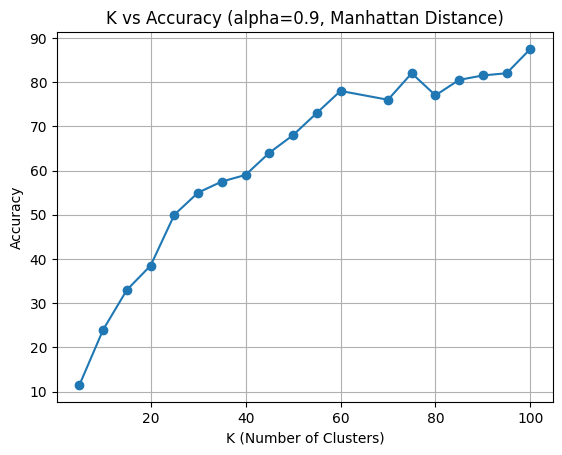

Loaded PCA data from cache.
Accuracy: 14.50%
Loaded PCA data from cache.
Accuracy: 34.00%
Loaded PCA data from cache.
Accuracy: 34.00%
Loaded PCA data from cache.
Accuracy: 65.50%
Loaded PCA data from cache.
Accuracy: 72.00%
Loaded PCA data from cache.
Accuracy: 80.50%
Loaded PCA data from cache.
Accuracy: 79.00%
Loaded PCA data from cache.
Accuracy: 86.00%
Loaded PCA data from cache.
Accuracy: 86.50%
Loaded PCA data from cache.
Accuracy: 87.50%
Loaded PCA data from cache.
Accuracy: 86.50%
Loaded PCA data from cache.
Accuracy: 79.00%


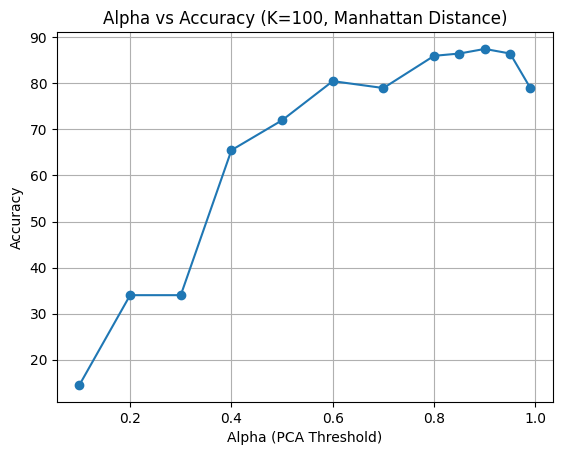

Loaded PCA data from cache.
Accuracy: 11.50%
Loaded PCA data from cache.
Accuracy: 24.00%
Loaded PCA data from cache.
Accuracy: 33.00%
Loaded PCA data from cache.
Accuracy: 38.50%
Loaded PCA data from cache.
Accuracy: 50.00%
Loaded PCA data from cache.
Accuracy: 55.00%
Loaded PCA data from cache.
Accuracy: 57.50%
Loaded PCA data from cache.
Accuracy: 59.00%
Loaded PCA data from cache.
Accuracy: 64.00%
Loaded PCA data from cache.
Accuracy: 68.00%
Loaded PCA data from cache.
Accuracy: 73.00%
Loaded PCA data from cache.
Accuracy: 78.00%
Loaded PCA data from cache.
Accuracy: 76.00%
Loaded PCA data from cache.
Accuracy: 82.00%
Loaded PCA data from cache.
Accuracy: 77.00%
Loaded PCA data from cache.
Accuracy: 80.50%
Loaded PCA data from cache.
Accuracy: 81.50%
Loaded PCA data from cache.
Accuracy: 82.00%
Loaded PCA data from cache.
Accuracy: 87.50%


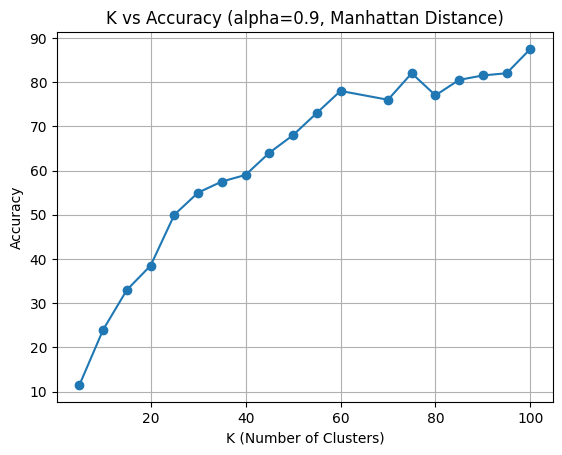

Loaded PCA data from cache.
Accuracy: 14.50%
Loaded PCA data from cache.
Accuracy: 34.00%
Loaded PCA data from cache.
Accuracy: 34.00%
Loaded PCA data from cache.
Accuracy: 65.50%
Loaded PCA data from cache.
Accuracy: 72.00%
Loaded PCA data from cache.
Accuracy: 80.50%
Loaded PCA data from cache.
Accuracy: 79.00%
Loaded PCA data from cache.
Accuracy: 86.00%
Loaded PCA data from cache.
Accuracy: 86.50%
Loaded PCA data from cache.
Accuracy: 87.50%
Loaded PCA data from cache.
Accuracy: 86.50%
Loaded PCA data from cache.
Accuracy: 79.00%


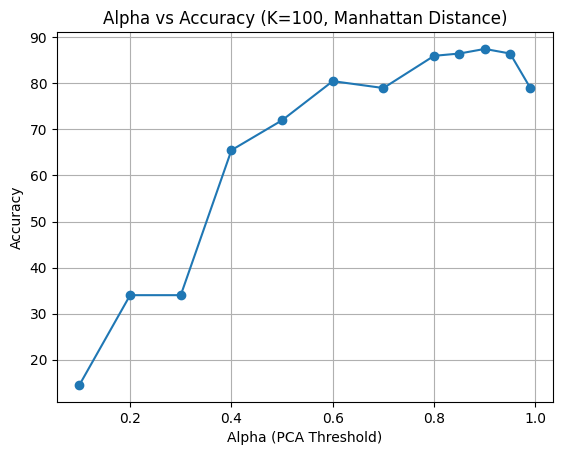

In [54]:
import matplotlib.pyplot as plt

def kmean_analysis(X, y):

    k_values = [5, 10, 15, 20, 25, 30,35, 40,45, 50, 55, 60,70, 75, 80, 85, 90, 95, 100]
    alpha_values = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8, 0.85, 0.9, 0.95, 0.99]
    
    acc_vs_k = []
    for K in k_values:
        accuracy = evaluate_model(X_train, y_train, X_test, y_test, n_clusters=K, alpha=0.9,random_initializations_limit=100, distance_strategy = ManhattanDistance) 
        acc_vs_k.append(accuracy)

    # Plot Accuracy vs K
    plt.figure()
    plt.plot(k_values, acc_vs_k, marker='o')
    plt.xlabel('K (Number of Clusters)')
    plt.ylabel('Accuracy')
    plt.title('K vs Accuracy (alpha=0.9, Manhattan Distance)')
    plt.grid(True)
    plt.show()

    acc_vs_alpha = []
    for alpha in alpha_values:
        accuracy = evaluate_model(X_train, y_train, X_test, y_test, n_clusters=100, alpha=alpha,random_initializations_limit=100, distance_strategy = ManhattanDistance)
        acc_vs_alpha.append(accuracy)

    # Plot Accuracy vs Alpha
    plt.figure()
    plt.plot(alpha_values, acc_vs_alpha, marker='o')
    plt.xlabel('Alpha (PCA Threshold)')
    plt.ylabel('Accuracy')
    plt.title('Alpha vs Accuracy (K=100, Manhattan Distance)')
    plt.grid(True)
    plt.show()

kmean_analysis(X_train, y_train)
kmean_analysis(X_test, y_test)
